# Matrixoperaties en Lineaire Transformaties

**Mathematical Foundations - IT & Artificial Intelligence**

---

## 3.0 Recap en Motivatie

In de vorige les hebben we gezien hoe één neuron werkt: het berekent het dot product van de input vector met zijn gewichten en telt daar een bias bij op. Dit is elegant voor één neuron, maar een echte netwerklaag bevat honderden of duizenden neuronen die allemaal tegelijk moeten worden berekend.

Stel je voor dat we 128 neuronen hebben in een hidden layer, elk verbonden met 784 inputs. Als we elk neuron apart zouden berekenen met een for-loop, zou dit traag en inefficiënt zijn. De oplossing is matrixvermenigvuldiging: één enkele operatie die alle 128 neuronen tegelijk berekent.

Dit is niet alleen eleganter, het is ook veel sneller. GPU's (Graphics Processing Units) zijn specifiek ontworpen om matrixoperaties massaal parallel uit te voeren. Dit is de reden waarom deep learning pas echt van de grond kwam toen onderzoekers ontdekten dat ze GPU's konden gebruiken voor neurale netwerken.

<center>
<img src="../../_static/img/les3/CPUGPU.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

In deze les leren we matrixvermenigvuldiging, hoe we een complete netwerklaag kunnen berekenen met één operatie, en hoe matrices geometrisch kunnen worden geïnterpreteerd als transformaties.

## 3.1 Leerdoelen

Na het doorwerken van deze les kun je matrixvermenigvuldiging uitvoeren en de dimensieregels toepassen. Je begrijpt hoe een volledige netwerklaag wordt berekend met één matrixoperatie. Je kunt lineaire transformaties geometrisch interpreteren, waaronder rotatie, schaling en projectie. Je kunt de transpose van een matrix berekenen en weet wanneer je deze nodig hebt. Tot slot herken je speciale matrices zoals de identiteitsmatrix en diagonaalmatrices.

In [1]:
# Importeer de benodigde libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

np.set_printoptions(precision=3, suppress=True)

# Laad MNIST
print("MNIST laden...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_mnist, y_mnist = mnist.data, mnist.target.astype(int)
print(f"Geladen: {len(X_mnist)} afbeeldingen")

MNIST laden...
Geladen: 70000 afbeeldingen


## 3.2 Matrixvermenigvuldiging

### De definitie

Matrixvermenigvuldiging is een operatie die twee matrices combineert tot een nieuwe matrix. Anders dan element-wise vermenigvuldiging, waarbij je simpelweg overeenkomstige elementen vermenigvuldigt, combineert matrixvermenigvuldiging rijen van de eerste matrix met kolommen van de tweede.

Als A een matrix is met m rijen en n kolommen, en B een matrix met n rijen en p kolommen, dan is het product C = A × B een matrix met m rijen en p kolommen. Elk element C[i,j] is het dot product van rij i van A met kolom j van B.

<center>
<img src="../../_static/img/les3/MatrixVermenigvuldiging1.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

Dit betekent dat het aantal kolommen van A gelijk moet zijn aan het aantal rijen van B. We noteren dit als: (m × n) × (n × p) = (m × p). De "binnenste" dimensies (beide n) moeten overeenkomen en verdwijnen in het resultaat.

In [2]:
# Eenvoudig voorbeeld: 2x3 matrix maal 3x2 matrix
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])  # 2x3

B = np.array([
    [7, 8],
    [9, 10],
    [11, 12]
])  # 3x2

print(f"Matrix A (shape {A.shape}):")
print(A)
print()
print(f"Matrix B (shape {B.shape}):")
print(B)
print()

# Matrixvermenigvuldiging
C = A @ B  # Of: np.matmul(A, B)

print(f"C = A @ B (shape {C.shape}):")
print(C)

Matrix A (shape (2, 3)):
[[1 2 3]
 [4 5 6]]

Matrix B (shape (3, 2)):
[[ 7  8]
 [ 9 10]
 [11 12]]

C = A @ B (shape (2, 2)):
[[ 58  64]
 [139 154]]


In [3]:
# Laten we C[0,0] stap voor stap berekenen
print("Berekening van C[0,0]:")
print(f"Rij 0 van A: {A[0]}")
print(f"Kolom 0 van B: {B[:, 0]}")
print(f"Dot product: {A[0,0]}×{B[0,0]} + {A[0,1]}×{B[1,0]} + {A[0,2]}×{B[2,0]}")
print(f"           = {A[0,0]*B[0,0]} + {A[0,1]*B[1,0]} + {A[0,2]*B[2,0]}")
print(f"           = {A[0] @ B[:, 0]}")
print()

# En C[1,1]
print("Berekening van C[1,1]:")
print(f"Rij 1 van A: {A[1]}")
print(f"Kolom 1 van B: {B[:, 1]}")
print(f"Dot product: {A[1,0]}×{B[0,1]} + {A[1,1]}×{B[1,1]} + {A[1,2]}×{B[2,1]}")
print(f"           = {A[1,0]*B[0,1]} + {A[1,1]*B[1,1]} + {A[1,2]*B[2,1]}")
print(f"           = {A[1] @ B[:, 1]}")

Berekening van C[0,0]:
Rij 0 van A: [1 2 3]
Kolom 0 van B: [ 7  9 11]
Dot product: 1×7 + 2×9 + 3×11
           = 7 + 18 + 33
           = 58

Berekening van C[1,1]:
Rij 1 van A: [4 5 6]
Kolom 1 van B: [ 8 10 12]
Dot product: 4×8 + 5×10 + 6×12
           = 32 + 50 + 72
           = 154


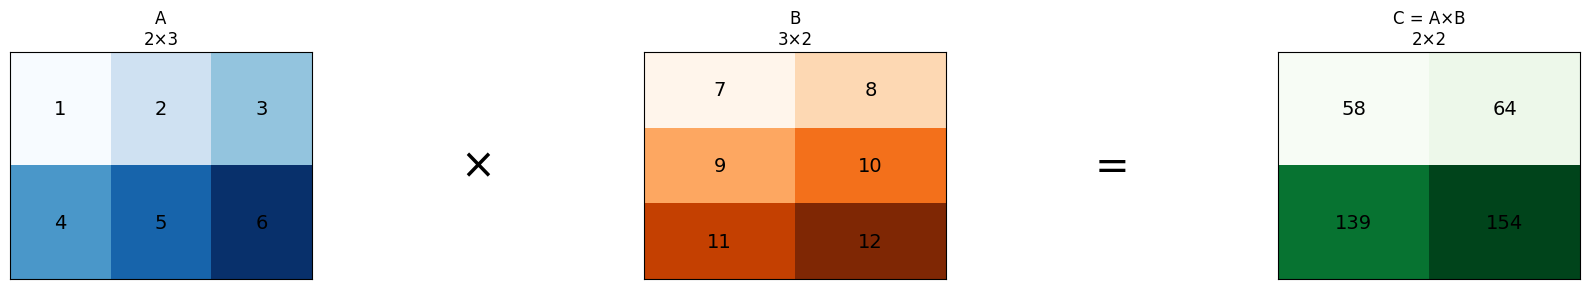

Dimensieregel: (2×3) × (3×2) = (2×2)
De binnenste dimensies (beide 3) moeten gelijk zijn.


In [4]:
# Visualisatie van matrixvermenigvuldiging
fig, axes = plt.subplots(1, 5, figsize=(16, 3))

# Matrix A
axes[0].imshow(A, cmap='Blues', aspect='auto')
axes[0].set_title(f'A\n{A.shape[0]}×{A.shape[1]}')
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        axes[0].text(j, i, str(A[i,j]), ha='center', va='center', fontsize=14)
axes[0].set_xticks([])
axes[0].set_yticks([])

# ×
axes[1].text(0.5, 0.5, '×', fontsize=30, ha='center', va='center')
axes[1].axis('off')

# Matrix B
axes[2].imshow(B, cmap='Oranges', aspect='auto')
axes[2].set_title(f'B\n{B.shape[0]}×{B.shape[1]}')
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        axes[2].text(j, i, str(B[i,j]), ha='center', va='center', fontsize=14)
axes[2].set_xticks([])
axes[2].set_yticks([])

# =
axes[3].text(0.5, 0.5, '=', fontsize=30, ha='center', va='center')
axes[3].axis('off')

# Matrix C
axes[4].imshow(C, cmap='Greens', aspect='auto')
axes[4].set_title(f'C = A×B\n{C.shape[0]}×{C.shape[1]}')
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        axes[4].text(j, i, str(C[i,j]), ha='center', va='center', fontsize=14)
axes[4].set_xticks([])
axes[4].set_yticks([])

plt.tight_layout()
plt.show()

print("Dimensieregel: (2×3) × (3×2) = (2×2)")
print("De binnenste dimensies (beide 3) moeten gelijk zijn.")

### Belangrijke eigenschappen

Matrixvermenigvuldiging heeft enkele belangrijke eigenschappen die je moet kennen. Ten eerste is het niet commutatief: in het algemeen geldt A × B ≠ B × A. Zelfs als beide producten gedefinieerd zijn, geven ze meestal verschillende resultaten. Dit is een belangrijk verschil met gewone vermenigvuldiging van getallen.

Ten tweede is matrixvermenigvuldiging wel associatief: (A × B) × C = A × (B × C). Dit betekent dat bij het vermenigvuldigen van meerdere matrices de volgorde van berekening niet uitmaakt, zolang de volgorde van de matrices zelf niet verandert.

Ten derde is het distributief over optelling: A × (B + C) = A × B + A × C. Dit is belangrijk voor het begrijpen van hoe neurale netwerken batch data verwerken.

In [5]:
# Niet commutatief: A × B ≠ B × A
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

AB = A @ B
BA = B @ A

print("Matrixvermenigvuldiging is NIET commutatief:\n")
print("A @ B =")
print(AB)
print()
print("B @ A =")
print(BA)
print()
print(f"A @ B == B @ A? {np.allclose(AB, BA)}")

Matrixvermenigvuldiging is NIET commutatief:

A @ B =
[[19 22]
 [43 50]]

B @ A =
[[23 34]
 [31 46]]

A @ B == B @ A? False


In [6]:
# Wel associatief: (A × B) × C = A × (B × C)
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
C = np.array([[9, 10], [11, 12]])

links = (A @ B) @ C
rechts = A @ (B @ C)

print("Matrixvermenigvuldiging is WEL associatief:\n")
print("(A @ B) @ C =")
print(links)
print()
print("A @ (B @ C) =")
print(rechts)
print()
print(f"(A @ B) @ C == A @ (B @ C)? {np.allclose(links, rechts)}")

Matrixvermenigvuldiging is WEL associatief:

(A @ B) @ C =
[[ 413  454]
 [ 937 1030]]

A @ (B @ C) =
[[ 413  454]
 [ 937 1030]]

(A @ B) @ C == A @ (B @ C)? True


### Vector-matrix vermenigvuldiging

Een speciaal geval van matrixvermenigvuldiging is wanneer één van de operanden een vector is. Een vector kan worden gezien als een matrix met één rij (rijvector) of één kolom (kolomvector).

Als x een rijvector is met shape (1, n) en W een matrix met shape (n, m), dan is x @ W een rijvector met shape (1, m). In de praktijk gebruiken we in NumPy vaak 1D arrays voor vectoren, en NumPy handelt de dimensies automatisch af.

In [7]:
# Vector-matrix vermenigvuldiging
x = np.array([1, 2, 3])  # Vector met 3 elementen
W = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])  # 3×4 matrix

print(f"Vector x: {x} (shape {x.shape})")
print(f"Matrix W (shape {W.shape}):")
print(W)
print()

result = x @ W
print(f"x @ W = {result} (shape {result.shape})")
print()
print("Elke output is het dot product van x met een kolom van W:")
for j in range(W.shape[1]):
    print(f"  Output {j}: x · W[:,{j}] = {x} · {W[:,j]} = {x @ W[:,j]}")

Vector x: [1 2 3] (shape (3,))
Matrix W (shape (3, 4)):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

x @ W = [38 44 50 56] (shape (4,))

Elke output is het dot product van x met een kolom van W:
  Output 0: x · W[:,0] = [1 2 3] · [1 5 9] = 38
  Output 1: x · W[:,1] = [1 2 3] · [ 2  6 10] = 44
  Output 2: x · W[:,2] = [1 2 3] · [ 3  7 11] = 50
  Output 3: x · W[:,3] = [1 2 3] · [ 4  8 12] = 56


## 3.3 Een Netwerklaag als Matrixoperatie

Nu komen we bij de kerntoepassing van matrixvermenigvuldiging in neurale netwerken. Een laag van een neuraal netwerk kan volledig worden beschreven als een matrixoperatie gevolgd door een bias-optelling.

Stel we hebben een input vector x met 784 elementen (een MNIST afbeelding) en we willen deze door een laag sturen met 128 neuronen. Elk neuron heeft 784 gewichten (één voor elke input) plus een bias. In totaal hebben we dus 784 × 128 = 100.352 gewichten en 128 biases.

We organiseren de gewichten in een matrix W met shape (784, 128), waarbij kolom j de gewichten bevat van neuron j. De biases vormen een vector b met shape (128,). De output van de laag is dan simpelweg: y = x @ W + b.

In [8]:
# Een enkele netwerklaag
input_size = 784
output_size = 128

# Random gewichten en biases (in de praktijk worden deze getraind)
np.random.seed(42)
W = np.random.randn(input_size, output_size) * 0.01  # Kleine random waarden
b = np.zeros(output_size)  # Biases starten vaak op 0

print(f"Input size: {input_size}")
print(f"Output size: {output_size}")
print(f"Weights shape: {W.shape}")
print(f"Biases shape: {b.shape}")
print(f"Totaal aantal parameters: {W.size + b.size:,}")

Input size: 784
Output size: 128
Weights shape: (784, 128)
Biases shape: (128,)
Totaal aantal parameters: 100,480


In [9]:
# Forward pass voor één afbeelding
x = X_mnist[0]  # Eerste MNIST afbeelding
print(f"Input shape: {x.shape}")

# De volledige laag in één operatie!
y = x @ W + b

print(f"Output shape: {y.shape}")
print(f"\nEerste 10 output waarden: {y[:10]}")
print(f"Min: {y.min():.4f}, Max: {y.max():.4f}, Mean: {y.mean():.4f}")

Input shape: (784,)
Output shape: (128,)

Eerste 10 output waarden: [ 16.337   7.325 -13.897 -59.768   3.783 -37.259  -7.491  -8.998  -7.324
 -56.121]
Min: -59.7681, Max: 77.2440, Mean: -1.4908


In [10]:
# Vergelijk met de "langzame" manier: neuron voor neuron
y_slow = np.zeros(output_size)
for j in range(output_size):
    # Neuron j: dot product met kolom j van W, plus bias j
    y_slow[j] = x @ W[:, j] + b[j]

print("Vergelijking met neuron-voor-neuron berekening:")
print(f"Resultaten identiek? {np.allclose(y, y_slow)}")
print()
print("De matrixvermenigvuldiging doet exact hetzelfde,")
print("maar veel efficiënter (vooral op GPU's)!")

Vergelijking met neuron-voor-neuron berekening:
Resultaten identiek? True

De matrixvermenigvuldiging doet exact hetzelfde,
maar veel efficiënter (vooral op GPU's)!


### Batch processing

Het echte voordeel van matrixoperaties komt naar voren bij batch processing. In plaats van één afbeelding tegelijk te verwerken, kunnen we een hele batch van bijvoorbeeld 32 afbeeldingen tegelijk door de laag sturen.

<center>
<img src="../../_static/img/les3/batchProc.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

Als X een matrix is met shape (32, 784), waarbij elke rij een afbeelding is, dan is X @ W een matrix met shape (32, 128), waarbij elke rij de output is voor de corresponderende afbeelding. De bias wordt via broadcasting bij elke rij opgeteld.

In [11]:
# Batch processing: meerdere afbeeldingen tegelijk
batch_size = 32
X_batch = X_mnist[:batch_size]  # Eerste 32 afbeeldingen

print(f"Batch input shape: {X_batch.shape}")
print(f"  → {X_batch.shape[0]} afbeeldingen van {X_batch.shape[1]} pixels")
print()

# Forward pass voor de hele batch in één keer!
Y_batch = X_batch @ W + b

print(f"Batch output shape: {Y_batch.shape}")
print(f"  → {Y_batch.shape[0]} outputs van {Y_batch.shape[1]} waarden")
print()
print("Dimensieregel: (32×784) @ (784×128) + (128,) = (32×128)")

Batch input shape: (32, 784)
  → 32 afbeeldingen van 784 pixels

Batch output shape: (32, 128)
  → 32 outputs van 128 waarden

Dimensieregel: (32×784) @ (784×128) + (128,) = (32×128)


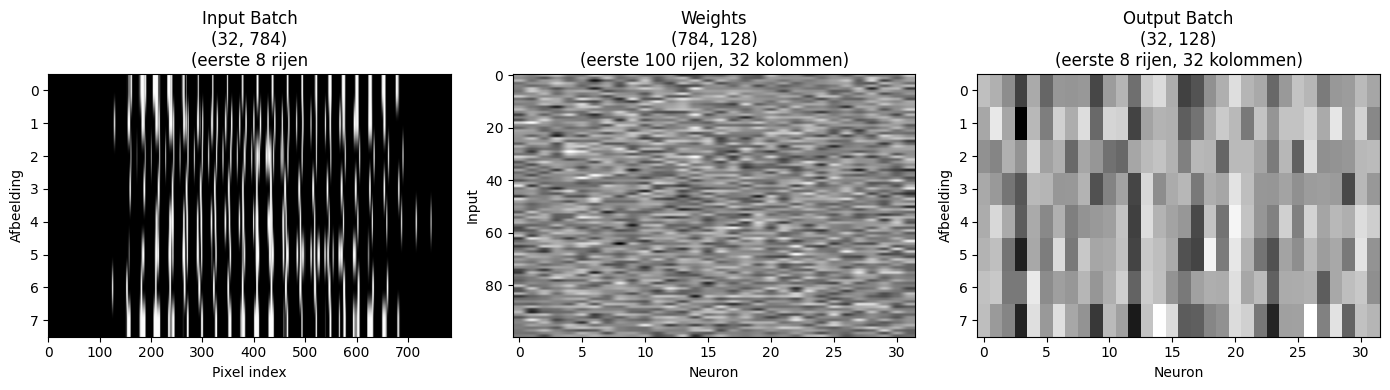

In [29]:
# Visualiseer wat er gebeurt
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Input batch (toon subset voor visualisatie)
axes[0].imshow(X_batch[:8, :], cmap='gray', aspect='auto')
axes[0].set_title(f'Input Batch\n{X_batch.shape}\n(eerste 8 rijen')
axes[0].set_xlabel('Pixel index')
axes[0].set_ylabel('Afbeelding')

# Gewichten (toon subset)
axes[1].imshow(W[:100, :32], cmap='gray', aspect='auto')
axes[1].set_title(f'Weights\n{W.shape}\n(eerste 100 rijen, 32 kolommen)')
axes[1].set_xlabel('Neuron')
axes[1].set_ylabel('Input')

# Output batch
axes[2].imshow(Y_batch[:8, :32], cmap='gray', aspect='auto')
axes[2].set_title(f'Output Batch\n{Y_batch.shape}\n(eerste 8 rijen, 32 kolommen)')
axes[2].set_xlabel('Neuron')
axes[2].set_ylabel('Afbeelding')

plt.tight_layout()
plt.show()

### Een Layer class implementeren

Laten we dit formaliseren in een Python class die we later kunnen hergebruiken.

In [13]:
class LinearLayer:
    """Een lineaire laag van een neuraal netwerk."""
    
    def __init__(self, input_size, output_size):
        """Initialiseer de laag met random gewichten."""
        # Xavier/Glorot initialisatie voor betere training
        scale = np.sqrt(2.0 / input_size)
        self.W = np.random.randn(input_size, output_size) * scale
        self.b = np.zeros(output_size)
        
    def forward(self, X):
        """Bereken de output voor input X."""
        return X @ self.W + self.b
    
    def __repr__(self):
        return f"LinearLayer({self.W.shape[0]} → {self.W.shape[1]})"


# Test de class
layer = LinearLayer(784, 128)
print(layer)
print(f"Parameters: {layer.W.size + layer.b.size:,}")
print()

# Forward pass
output = layer.forward(X_mnist[:10])
print(f"Input shape: (10, 784)")
print(f"Output shape: {output.shape}")

LinearLayer(784 → 128)
Parameters: 100,480

Input shape: (10, 784)
Output shape: (10, 128)


## 3.4 Lineaire Transformaties

Matrixvermenigvuldiging doet meer dan alleen getallen combineren. Geometrisch gezien transformeert een matrix vectoren van de ene ruimte naar de andere. Dit concept heet een lineaire transformatie.

Een lineaire transformatie heeft twee belangrijke eigenschappen. Ten eerste behoudt het de oorsprong: als je de nulvector transformeert, krijg je weer de nulvector. Ten tweede behoudt het lineaire combinaties: als je twee vectoren optelt en dan transformeert, krijg je hetzelfde resultaat als wanneer je eerst transformeert en dan optelt.

We kunnen lineaire transformaties het beste begrijpen door te kijken naar 2D-voorbeelden, die we gemakkelijk kunnen visualiseren.

In [14]:
# Helper functie voor het visualiseren van 2D transformaties
def plot_transformation(matrix, title, ax):
    """Visualiseer het effect van een matrix op een vierkant en grid."""
    # Maak een vierkant
    square = np.array([
        [0, 0], [1, 0], [1, 1], [0, 1], [0, 0]
    ]).T
    
    # Maak een grid van punten
    grid_x, grid_y = np.meshgrid(np.linspace(-0.2, 1.2, 8), np.linspace(-0.2, 1.2, 8))
    grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()])
    
    # Transformeer
    square_transformed = matrix @ square
    grid_transformed = matrix @ grid_points
    
    # Plot origineel (licht)
    ax.plot(square[0], square[1], 'b-', alpha=0.3, linewidth=2)
    ax.scatter(grid_points[0], grid_points[1], c='blue', alpha=0.2, s=20)
    
    # Plot getransformeerd (donker)
    ax.plot(square_transformed[0], square_transformed[1], 'r-', linewidth=2)
    ax.scatter(grid_transformed[0], grid_transformed[1], c='red', alpha=0.6, s=20)
    
    ax.set_xlim(-1.5, 2.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(f'{title}\n{matrix[0]}\n{matrix[1]}')

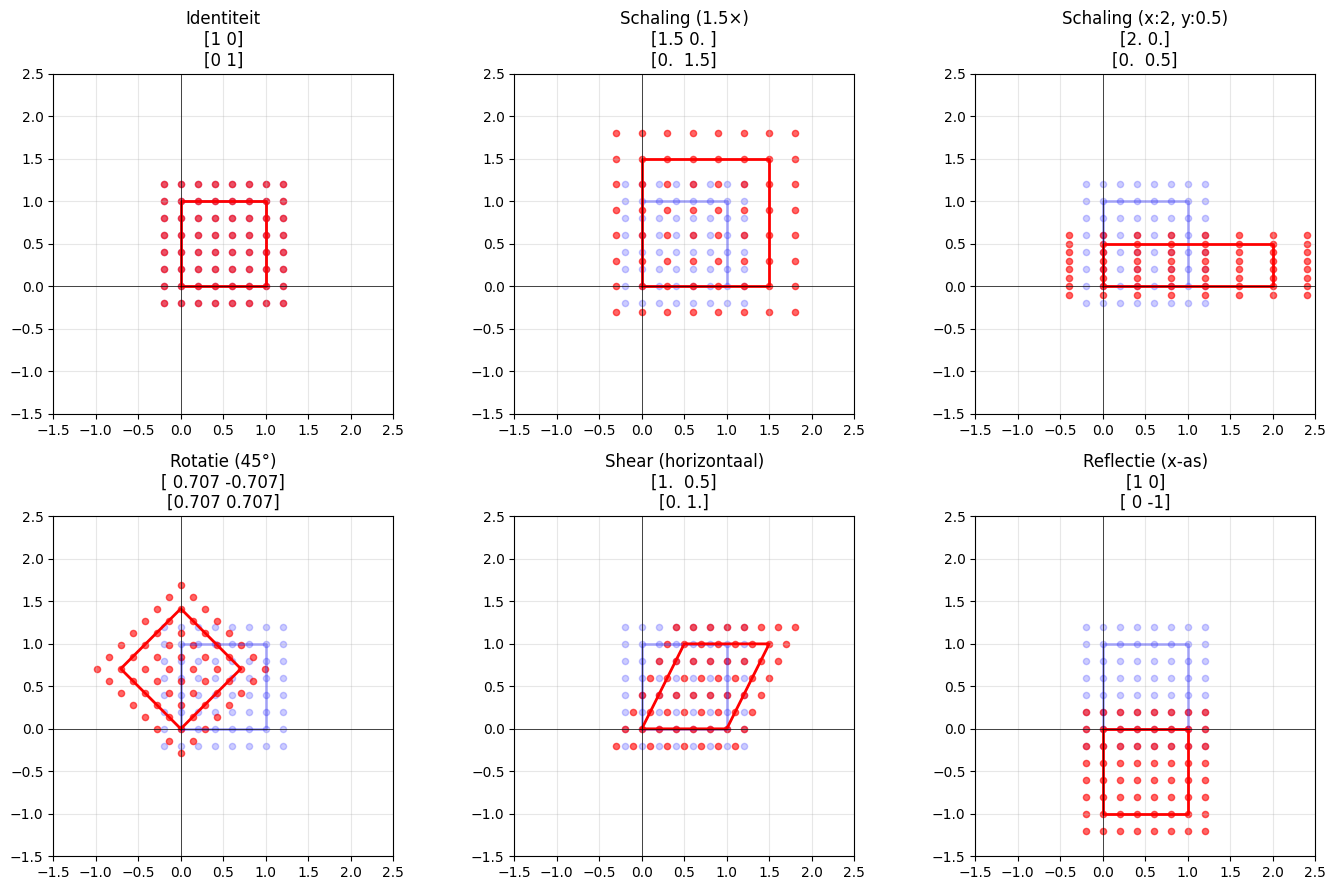

Blauw/licht = origineel, Rood/donker = getransformeerd


In [15]:
# Verschillende 2D transformaties
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Identiteit (geen verandering)
I = np.array([[1, 0], [0, 1]])
plot_transformation(I, 'Identiteit', axes[0, 0])

# Schaling (uniform)
S = np.array([[1.5, 0], [0, 1.5]])
plot_transformation(S, 'Schaling (1.5×)', axes[0, 1])

# Schaling (niet-uniform)
S2 = np.array([[2, 0], [0, 0.5]])
plot_transformation(S2, 'Schaling (x:2, y:0.5)', axes[0, 2])

# Rotatie (45 graden)
theta = np.pi / 4  # 45 graden
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta), np.cos(theta)]])
plot_transformation(R, 'Rotatie (45°)', axes[1, 0])

# Shear (horizontaal)
Sh = np.array([[1, 0.5], [0, 1]])
plot_transformation(Sh, 'Shear (horizontaal)', axes[1, 1])

# Reflectie (over x-as)
Ref = np.array([[1, 0], [0, -1]])
plot_transformation(Ref, 'Reflectie (x-as)', axes[1, 2])

plt.tight_layout()
plt.show()

print("Blauw/licht = origineel, Rood/donker = getransformeerd")

### Samenstelling van transformaties

Een van de krachtigste aspecten van lineaire transformaties is dat ze kunnen worden samengesteld door matrixvermenigvuldiging. Als je eerst transformatie A toepast en dan transformatie B, is het resultaat hetzelfde als de transformatie B × A toepassen.

Let op de volgorde: de matrix die het laatst wordt toegepast staat vooraan in het product. Dit komt omdat we vectoren van rechts vermenigvuldigen: (B × A) × v = B × (A × v).

<center>
<img src="../../_static/img/les3/Transformatie.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

Dit is precies wat er gebeurt in een neuraal netwerk: elke laag past een transformatie toe, en het totale effect is de samenstelling van al deze transformaties.

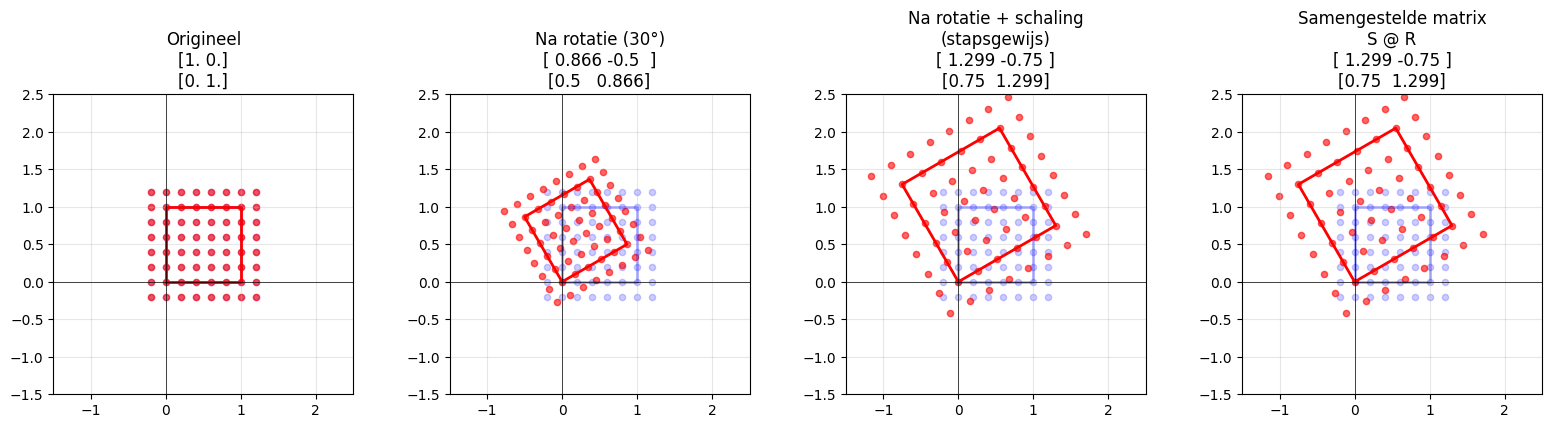

Rotatiematrix R:
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]

Schalingsmatrix S:
[[1.5 0. ]
 [0.  1.5]]

Samengesteld S @ R:
[[ 1.299 -0.75 ]
 [ 0.75   1.299]]


In [16]:
# Samenstelling: eerst roteren, dan schalen
theta = np.pi / 6  # 30 graden
R = np.array([[np.cos(theta), -np.sin(theta)], 
              [np.sin(theta), np.cos(theta)]])
S = np.array([[1.5, 0], [0, 1.5]])

# Samengestelde transformatie: S × R (eerst R, dan S)
combined = S @ R

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Origineel
plot_transformation(np.eye(2), 'Origineel', axes[0])

# Na rotatie
plot_transformation(R, 'Na rotatie (30°)', axes[1])

# Na rotatie + schaling (stapsgewijs)
plot_transformation(combined, 'Na rotatie + schaling\n(stapsgewijs)', axes[2])

# Samengestelde matrix in één keer
plot_transformation(combined, 'Samengestelde matrix\nS @ R', axes[3])

plt.tight_layout()
plt.show()

print(f"Rotatiematrix R:\n{R.round(3)}")
print(f"\nSchalingsmatrix S:\n{S}")
print(f"\nSamengesteld S @ R:\n{combined.round(3)}")

### Link naar neurale netwerken

In een neuraal netwerk is elke laag in essentie een lineaire transformatie (de matrixvermenigvuldiging met gewichten) gevolgd door een niet-lineaire activatiefunctie. De lineaire transformatie kan de data roteren, schalen, projecteren en op allerlei manieren vervormen.

Het is de combinatie van lineaire transformaties met niet-lineaire activatiefuncties die neurale netwerken zo krachtig maakt. Zonder de niet-lineariteit zou een netwerk met meerdere lagen wiskundig equivalent zijn aan één enkele lineaire transformatie, omdat de samenstelling van lineaire functies weer lineair is.

## 3.5 Speciale Matrices

Sommige matrices hebben speciale eigenschappen die ze bijzonder nuttig maken. Het is belangrijk om deze te herkennen.

<center>
<img src="../../_static/img/les3/SpecialMatrices.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

### De identiteitsmatrix

De identiteitsmatrix I is een vierkante matrix met enen op de diagonaal en nullen elders. Het is het equivalent van het getal 1 voor matrices: I × A = A × I = A. De identiteitsmatrix verandert niets aan een vector of matrix.

In [17]:
# Identiteitsmatrix
I = np.eye(3)  # 3×3 identiteitsmatrix
print("Identiteitsmatrix I:")
print(I)
print()

A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("Matrix A:")
print(A)
print()

print("I @ A:")
print(I @ A)
print()

print("A @ I:")
print(A @ I)
print()

print(f"I @ A == A? {np.allclose(I @ A, A)}")
print(f"A @ I == A? {np.allclose(A @ I, A)}")

Identiteitsmatrix I:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Matrix A:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

I @ A:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

A @ I:
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

I @ A == A? True
A @ I == A? True


### Diagonaalmatrices

Een diagonaalmatrix heeft alleen waarden op de hoofddiagonaal, de rest is nul. Als transformatie schaalt een diagonaalmatrix elke as onafhankelijk. De identiteitsmatrix is een speciaal geval van een diagonaalmatrix.

In [18]:
# Diagonaalmatrix maken
d = np.array([2, 3, 0.5])
D = np.diag(d)
print("Diagonaalmatrix D:")
print(D)
print()

# Effect op een vector
v = np.array([1, 1, 1])
print(f"Vector v: {v}")
print(f"D @ v: {D @ v}")
print()
print("Elke component wordt geschaald met de corresponderende diagonaalwaarde.")

Diagonaalmatrix D:
[[2.  0.  0. ]
 [0.  3.  0. ]
 [0.  0.  0.5]]

Vector v: [1 1 1]
D @ v: [2.  3.  0.5]

Elke component wordt geschaald met de corresponderende diagonaalwaarde.


### De transpose

De transpose van een matrix A, genoteerd als Aᵀ, is de matrix die je krijgt door rijen en kolommen te verwisselen. Element A[i,j] wordt Aᵀ[j,i].

<center>
<img src="../../_static/img/les3/Transpose.png" alt="Beschrijving van de afbeelding" width="500px" />
</center>

De transpose heeft enkele belangrijke eigenschappen. Ten eerste geldt (Aᵀ)ᵀ = A, de transpose van de transpose is de originele matrix. Ten tweede geldt (A × B)ᵀ = Bᵀ × Aᵀ, let op de omgekeerde volgorde. De transpose is cruciaal bij backpropagation in neurale netwerken.

In [19]:
# Transpose
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])  # 2×3

print(f"Matrix A (shape {A.shape}):")
print(A)
print()

print(f"Transpose Aᵀ (shape {A.T.shape}):")
print(A.T)
print()

print("Rijen worden kolommen en vice versa.")

Matrix A (shape (2, 3)):
[[1 2 3]
 [4 5 6]]

Transpose Aᵀ (shape (3, 2)):
[[1 4]
 [2 5]
 [3 6]]

Rijen worden kolommen en vice versa.


In [20]:
# Belangrijke eigenschap: (A × B)ᵀ = Bᵀ × Aᵀ
A = np.array([[1, 2], [3, 4], [5, 6]])  # 3×2
B = np.array([[7, 8, 9], [10, 11, 12]])  # 2×3

AB = A @ B  # 3×3
AB_T = AB.T

BT_AT = B.T @ A.T

print("(A @ B)ᵀ:")
print(AB_T)
print()

print("Bᵀ @ Aᵀ:")
print(BT_AT)
print()

print(f"Gelijk? {np.allclose(AB_T, BT_AT)}")
print()
print("Let op de omgekeerde volgorde! Dit is cruciaal bij backpropagation.")

(A @ B)ᵀ:
[[ 27  61  95]
 [ 30  68 106]
 [ 33  75 117]]

Bᵀ @ Aᵀ:
[[ 27  61  95]
 [ 30  68 106]
 [ 33  75 117]]

Gelijk? True

Let op de omgekeerde volgorde! Dit is cruciaal bij backpropagation.


### Symmetrische matrices

Een matrix A is symmetrisch als A = Aᵀ. Dit betekent dat de matrix gespiegeld is over de hoofddiagonaal. Symmetrische matrices komen veel voor in statistiek en machine learning, bijvoorbeeld covariantiematrices.

In [21]:
# Symmetrische matrix
A_sym = np.array([
    [1, 2, 3],
    [2, 4, 5],
    [3, 5, 6]
])

print("Symmetrische matrix A:")
print(A_sym)
print()

print("Transpose Aᵀ:")
print(A_sym.T)
print()

print(f"A == Aᵀ? {np.allclose(A_sym, A_sym.T)}")
print()

# Voorbeeld: covariantiematrix is altijd symmetrisch
data = np.random.randn(100, 3)  # 100 samples, 3 features
cov_matrix = np.cov(data.T)
print("Covariantiematrix (altijd symmetrisch):")
print(cov_matrix.round(3))
print(f"Symmetrisch? {np.allclose(cov_matrix, cov_matrix.T)}")

Symmetrische matrix A:
[[1 2 3]
 [2 4 5]
 [3 5 6]]

Transpose Aᵀ:
[[1 2 3]
 [2 4 5]
 [3 5 6]]

A == Aᵀ? True

Covariantiematrix (altijd symmetrisch):
[[ 0.625 -0.059  0.115]
 [-0.059  0.859 -0.188]
 [ 0.115 -0.188  1.242]]
Symmetrisch? True


## 3.6 Toepassing: Forward Pass van een Mini-Netwerk

Laten we alles samenvoegen en een complete forward pass implementeren voor een klein neuraal netwerk. We bouwen een netwerk met drie lagen: Input (784) → Hidden (128) → Output (10).

Dit netwerk zou in principe MNIST cijfers kunnen classificeren, al zal het met random gewichten alleen maar willekeurige outputs geven. Het punt is om te zien hoe de matrixoperaties samenwerken.

In [22]:
def relu(x):
    """ReLU activatiefunctie: max(0, x)"""
    return np.maximum(0, x)

def softmax(x):
    """Softmax: converteert naar kansverdeling."""
    # Numeriek stabiele versie
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)


class MiniNetwork:
    """Een simpel 2-laags netwerk voor MNIST."""
    
    def __init__(self):
        # Laag 1: 784 → 128
        self.W1 = np.random.randn(784, 128) * np.sqrt(2.0 / 784)
        self.b1 = np.zeros(128)
        
        # Laag 2: 128 → 10
        self.W2 = np.random.randn(128, 10) * np.sqrt(2.0 / 128)
        self.b2 = np.zeros(10)
    
    def forward(self, X):
        """Forward pass door het netwerk."""
        # Laag 1: linear + ReLU
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        
        # Laag 2: linear + softmax
        self.z2 = self.a1 @ self.W2 + self.b2
        self.output = softmax(self.z2)
        
        return self.output
    
    def predict(self, X):
        """Geef de voorspelde klasse."""
        probs = self.forward(X)
        return np.argmax(probs, axis=-1)
    
    def count_parameters(self):
        """Tel het totaal aantal parameters."""
        return self.W1.size + self.b1.size + self.W2.size + self.b2.size


# Maak het netwerk
np.random.seed(42)
network = MiniNetwork()

print("Mini-netwerk architectuur:")
print(f"  Input:  784 (28×28 pixels)")
print(f"  Hidden: 128 (met ReLU)")
print(f"  Output: 10  (met softmax)")
print()
print(f"Totaal parameters: {network.count_parameters():,}")
print(f"  W1: {network.W1.shape} = {network.W1.size:,}")
print(f"  b1: {network.b1.shape} = {network.b1.size}")
print(f"  W2: {network.W2.shape} = {network.W2.size:,}")
print(f"  b2: {network.b2.shape} = {network.b2.size}")

Mini-netwerk architectuur:
  Input:  784 (28×28 pixels)
  Hidden: 128 (met ReLU)
  Output: 10  (met softmax)

Totaal parameters: 101,770
  W1: (784, 128) = 100,352
  b1: (128,) = 128
  W2: (128, 10) = 1,280
  b2: (10,) = 10


In [23]:
# Forward pass voor één afbeelding
x = X_mnist[0:1]  # Shape (1, 784) - batch van 1
true_label = y_mnist[0]

output = network.forward(x)
prediction = network.predict(x)[0]

print(f"Echte label: {true_label}")
print(f"Voorspelling: {prediction}")
print()
print("Output kansen per klasse:")
for i in range(10):
    bar = "█" * int(output[0, i] * 50)
    print(f"  {i}: {output[0, i]:.4f} {bar}")

Echte label: 5
Voorspelling: 7

Output kansen per klasse:
  0: 0.0021 
  1: 0.0000 
  2: 0.0000 
  3: 0.0000 
  4: 0.0000 
  5: 0.0000 
  6: 0.0000 
  7: 0.9979 █████████████████████████████████████████████████
  8: 0.0000 
  9: 0.0000 


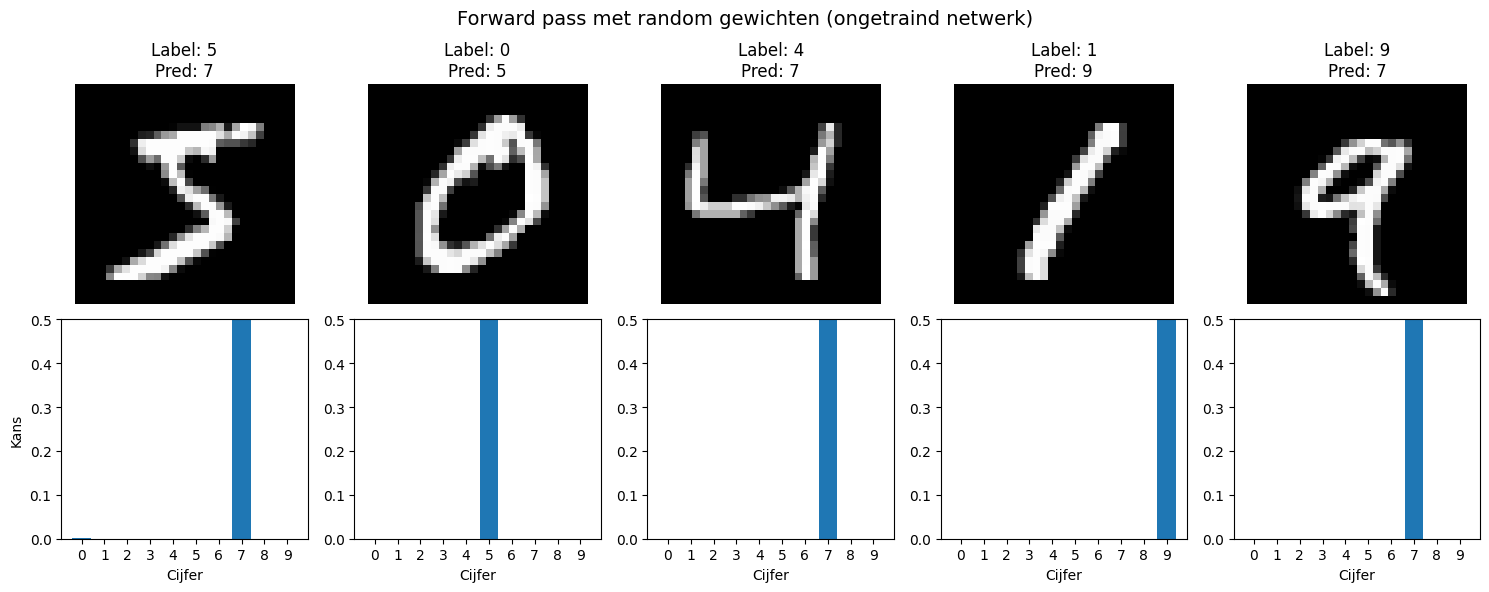

Met random gewichten zijn de voorspellingen willekeurig.
Het netwerk moet nog getraind worden om te leren!


In [24]:
# Visualiseer de forward pass voor meerdere afbeeldingen
n_samples = 5
X_sample = X_mnist[:n_samples]
y_sample = y_mnist[:n_samples]

outputs = network.forward(X_sample)
predictions = network.predict(X_sample)

fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))

for i in range(n_samples):
    # Afbeelding
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Label: {y_sample[i]}\nPred: {predictions[i]}')
    axes[0, i].axis('off')
    
    # Output kansen
    axes[1, i].bar(range(10), outputs[i])
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_ylim(0, 0.5)
    axes[1, i].set_xlabel('Cijfer')
    if i == 0:
        axes[1, i].set_ylabel('Kans')

plt.suptitle('Forward pass met random gewichten (ongetraind netwerk)', fontsize=14)
plt.tight_layout()
plt.show()

print("Met random gewichten zijn de voorspellingen willekeurig.")
print("Het netwerk moet nog getraind worden om te leren!")

In [25]:
# Laten we de shapes door het netwerk volgen
X_batch = X_mnist[:32]  # Batch van 32

print("Data shapes tijdens forward pass:")
print(f"\nInput X:        {X_batch.shape}")
print(f"                ↓")
print(f"W1:             {network.W1.shape}")
print(f"X @ W1:         {(X_batch @ network.W1).shape}")
print(f"+ b1:           {network.b1.shape} (broadcast)")
print(f"z1:             {(X_batch @ network.W1 + network.b1).shape}")
print(f"a1 = ReLU(z1):  {relu(X_batch @ network.W1 + network.b1).shape}")
print(f"                ↓")
a1 = relu(X_batch @ network.W1 + network.b1)
print(f"W2:             {network.W2.shape}")
print(f"a1 @ W2:        {(a1 @ network.W2).shape}")
print(f"+ b2:           {network.b2.shape} (broadcast)")
print(f"z2:             {(a1 @ network.W2 + network.b2).shape}")
z2 = a1 @ network.W2 + network.b2
print(f"softmax(z2):    {softmax(z2).shape}")
print(f"                ↓")
print(f"Output:         (32, 10) - 32 kansverdelingen over 10 klassen")

Data shapes tijdens forward pass:

Input X:        (32, 784)
                ↓
W1:             (784, 128)
X @ W1:         (32, 128)
+ b1:           (128,) (broadcast)
z1:             (32, 128)
a1 = ReLU(z1):  (32, 128)
                ↓
W2:             (128, 10)
a1 @ W2:        (32, 10)
+ b2:           (10,) (broadcast)
z2:             (32, 10)
softmax(z2):    (32, 10)
                ↓
Output:         (32, 10) - 32 kansverdelingen over 10 klassen


## 3.7 Samenvatting en Vooruitblik

### Kernconcepten

In deze les hebben we geleerd hoe matrixvermenigvuldiging werkt en waarom het zo fundamenteel is voor neurale netwerken. De kernformule (m × n) × (n × p) = (m × p) bepaalt wanneer matrices kunnen worden vermenigvuldigd en wat de resulterende dimensies zijn.

We hebben gezien dat een complete netwerklaag kan worden berekend met één matrixoperatie: y = X @ W + b. Dit is niet alleen elegant maar ook efficiënt, omdat GPU's geoptimaliseerd zijn voor matrixoperaties.

Geometrisch hebben we gezien dat matrixvermenigvuldiging lineaire transformaties uitvoert: rotaties, schalingen, reflecties en meer. Een neuraal netwerk is een reeks van zulke transformaties, afgewisseld met niet-lineaire activatiefuncties.

We hebben speciale matrices leren kennen: de identiteitsmatrix die niets verandert, diagonaalmatrices die onafhankelijk schalen, en de transpose die rijen en kolommen verwisselt.

### Link naar het neurale netwerk

We hebben nu een volledig werkende forward pass voor een mini-MNIST-netwerk. De data stroomt als volgt: Input (784) → Hidden (128) (via W1 → ReLU) → Output (10) (via W2 → Softmax). Met random gewichten zijn de outputs willekeurig, maar de structuur is er.

### Volgende les

In les 4 leren we over de inverse van een matrix en stelsels van vergelijkingen oplossen. Dit is het laatste onderdeel van lineaire algebra voordat we beginnen aan calculus, waar we leren hoe een netwerk daadwerkelijk leert door gradient descent.

### Checklist

Voordat je verdergaat, controleer of je het volgende begrijpt:

1. Hoe bereken je het product van twee matrices?

2. Wat is de dimensieregel voor matrixvermenigvuldiging?

3. Waarom is A × B niet gelijk aan B × A?

4. Hoe wordt een netwerklaag berekend met matrixvermenigvuldiging?

5. Wat doet de transpose operatie?

Als je deze vragen kunt beantwoorden, ben je klaar voor les 4!